# Snorkel weak supervision using schema-based financial statements

This notebook creates a **schema-aligned** financial statements dataset and applies **Snorkel** labeling functions to infer economic-cycle labels.

Economic-cycle label IDs:
- `0 = contraction`
- `1 = slowdown`
- `2 = expansion`
- `3 = recovery`

The generated CSV is saved in the same folder as this notebook.


## 1. Imports and setup

In [108]:
# If needed:
# %pip install snorkel pandas numpy scikit-learn

import numpy as np
import pandas as pd

from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from sklearn.metrics import classification_report, confusion_matrix


## 2. Generate a 200-row schema-based statements dataset

Columns are selected directly from `SCHEMA_01_STATEMENTS.txt` and expressed as numeric annual values.


In [109]:
rng = np.random.default_rng(123)
n_per_phase = 50

PHASES = {0: "contraction", 1: "slowdown", 2: "expansion", 3: "recovery"}

# Schema-aligned columns (subset across Income Statement / Balance Sheet / Cash Flow)
SCHEMA_COLS = [
    "Total revenue",
    "Operating income",
    "Net income",
    "EBITDA",
    "EBIT",
    "Total operating expenses",
    "Total interest expense (banks)",
    "Taxes",
    "Total assets",
    "Total liabilities",
    "Total equity",
    "Net debt",
    "Cash and short term investments",
    "Total debt",
    "Net loans",
    "Loan loss allowances (reserves)",
    "Total deposits",
    "Cash from operating activities",
    "Cash from investing activities",
    "Cash from financing activities",
    "Capital expenditures",
    "Free cash flow",
    "Interest paid",
    "Taxes paid",
]

def build_phase_block(phase_id: int, n: int) -> pd.DataFrame:
    # Start from scale variables to maintain coherent accounting relationships.
    if phase_id == 0:  # contraction
        revenue = rng.normal(820, 90, n)
        opex_ratio = rng.normal(0.88, 0.04, n)
        interest = rng.normal(48, 8, n)
        tax_rate = rng.normal(0.17, 0.03, n)
        assets = rng.normal(2600, 260, n)
        liabilities = rng.normal(2220, 200, n)
        debt = rng.normal(980, 120, n)
        cash_st = rng.normal(220, 35, n)
        net_loans = rng.normal(1240, 140, n)
        loan_loss = rng.normal(68, 12, n)
        deposits = rng.normal(1280, 130, n)
        cfo = rng.normal(52, 22, n)
        cfi = rng.normal(-66, 20, n)
        cff = rng.normal(28, 18, n)
        capex = rng.normal(-44, 10, n)
        interest_paid = rng.normal(52, 7, n)
        taxes_paid = rng.normal(12, 4, n)
    elif phase_id == 1:  # slowdown
        revenue = rng.normal(980, 95, n)
        opex_ratio = rng.normal(0.82, 0.04, n)
        interest = rng.normal(43, 7, n)
        tax_rate = rng.normal(0.19, 0.03, n)
        assets = rng.normal(2750, 250, n)
        liabilities = rng.normal(2260, 190, n)
        debt = rng.normal(940, 110, n)
        cash_st = rng.normal(245, 40, n)
        net_loans = rng.normal(1320, 135, n)
        loan_loss = rng.normal(52, 10, n)
        deposits = rng.normal(1360, 120, n)
        cfo = rng.normal(96, 28, n)
        cfi = rng.normal(-78, 22, n)
        cff = rng.normal(8, 16, n)
        capex = rng.normal(-56, 12, n)
        interest_paid = rng.normal(46, 6, n)
        taxes_paid = rng.normal(22, 5, n)
    elif phase_id == 2:  # expansion
        revenue = rng.normal(1260, 110, n)
        opex_ratio = rng.normal(0.72, 0.04, n)
        interest = rng.normal(34, 6, n)
        tax_rate = rng.normal(0.23, 0.03, n)
        assets = rng.normal(2980, 270, n)
        liabilities = rng.normal(2300, 200, n)
        debt = rng.normal(860, 100, n)
        cash_st = rng.normal(295, 45, n)
        net_loans = rng.normal(1410, 145, n)
        loan_loss = rng.normal(34, 8, n)
        deposits = rng.normal(1450, 130, n)
        cfo = rng.normal(182, 34, n)
        cfi = rng.normal(-116, 26, n)
        cff = rng.normal(-18, 18, n)
        capex = rng.normal(-88, 16, n)
        interest_paid = rng.normal(37, 6, n)
        taxes_paid = rng.normal(41, 7, n)
    else:  # recovery
        revenue = rng.normal(1120, 100, n)
        opex_ratio = rng.normal(0.77, 0.04, n)
        interest = rng.normal(39, 7, n)
        tax_rate = rng.normal(0.21, 0.03, n)
        assets = rng.normal(2860, 260, n)
        liabilities = rng.normal(2280, 190, n)
        debt = rng.normal(900, 105, n)
        cash_st = rng.normal(270, 40, n)
        net_loans = rng.normal(1370, 140, n)
        loan_loss = rng.normal(44, 9, n)
        deposits = rng.normal(1410, 125, n)
        cfo = rng.normal(138, 30, n)
        cfi = rng.normal(-98, 24, n)
        cff = rng.normal(-2, 16, n)
        capex = rng.normal(-72, 14, n)
        interest_paid = rng.normal(41, 6, n)
        taxes_paid = rng.normal(31, 6, n)

    total_opex = revenue * opex_ratio
    operating_income = revenue - total_opex
    ebit = operating_income + rng.normal(0, 8, n)
    ebitda = ebit + np.abs(rng.normal(42, 10, n))
    pretax_income = ebit - interest + rng.normal(0, 6, n)
    taxes = np.maximum(pretax_income * tax_rate, 1.0)
    net_income = pretax_income - taxes
    equity = assets - liabilities
    net_debt = debt - cash_st
    free_cash_flow = cfo + capex

    df_p = pd.DataFrame({
        "Total revenue": np.round(revenue, 2),
        "Operating income": np.round(operating_income, 2),
        "Net income": np.round(net_income, 2),
        "EBITDA": np.round(ebitda, 2),
        "EBIT": np.round(ebit, 2),
        "Total operating expenses": np.round(total_opex, 2),
        "Total interest expense (banks)": np.round(np.abs(interest), 2),
        "Taxes": np.round(np.maximum(taxes, 0), 2),
        "Total assets": np.round(assets, 2),
        "Total liabilities": np.round(liabilities, 2),
        "Total equity": np.round(equity, 2),
        "Net debt": np.round(net_debt, 2),
        "Cash and short term investments": np.round(np.maximum(cash_st, 1), 2),
        "Total debt": np.round(np.maximum(debt, 1), 2),
        "Net loans": np.round(np.maximum(net_loans, 1), 2),
        "Loan loss allowances (reserves)": np.round(np.maximum(loan_loss, 0.1), 2),
        "Total deposits": np.round(np.maximum(deposits, 1), 2),
        "Cash from operating activities": np.round(cfo, 2),
        "Cash from investing activities": np.round(cfi, 2),
        "Cash from financing activities": np.round(cff, 2),
        "Capital expenditures": np.round(capex, 2),
        "Free cash flow": np.round(free_cash_flow, 2),
        "Interest paid": np.round(np.maximum(interest_paid, 0.1), 2),
        "Taxes paid": np.round(np.maximum(taxes_paid, 0.1), 2),
        "phase_true": phase_id,
    })
    return df_p

parts = [build_phase_block(pid, n_per_phase) for pid in [0, 1, 2, 3]]
df = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=12).reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head(8)


Rows: 200
Columns: 25


,Total revenue,Operating income,Net income,EBITDA,EBIT,Total operating expenses,Total interest expense (banks),Taxes,Total assets,Total liabilities,...,Loan loss allowances (reserves),Total deposits,Cash from operating activities,Cash from investing activities,Cash from financing activities,Capital expenditures,Free cash flow,Interest paid,Taxes paid,phase_true
0,921.41,54.57,-2.22,90.09,49.24,866.85,50.03,1.00,3004.19,2233.69,...,61.32,1204.77,34.13,-58.39,8.60,-55.89,-21.77,52.59,15.43,0
1,1137.99,331.21,254.17,381.05,331.54,806.78,32.66,55.73,2481.85,2344.95,...,54.02,1510.58,158.78,-110.35,16.64,-85.15,73.62,19.60,30.87,3
2,947.56,240.11,153.87,264.16,233.48,707.45,37.28,30.59,2909.67,2430.65,...,53.80,1575.54,134.32,-48.06,-11.61,-75.31,59.00,37.59,22.28,3
3,894.51,94.32,54.24,146.89,104.39,800.19,45.95,9.48,2480.90,2286.96,...,42.88,1222.40,37.21,-65.79,6.97,-40.37,-3.16,52.18,14.33,0
4,946.77,122.97,74.45,153.73,121.61,823.80,27.74,14.72,2644.13,2215.96,...,36.76,1458.94,76.94,-60.62,-14.91,-51.56,25.37,46.99,14.37,1
5,682.67,97.17,47.53,132.45,87.16,585.49,34.51,9.31,2717.75,2126.69,...,47.64,977.74,75.63,-76.28,12.17,-67.37,8.26,44.16,2.57,0
6,1102.27,214.68,139.77,224.53,204.11,887.59,39.51,24.22,2519.70,1906.04,...,32.70,1399.78,123.96,-61.74,34.19,-73.82,50.13,47.81,10.68,1
7,930.36,50.54,12.71,110.87,56.42,879.82,42.35,2.72,2014.67,2143.95,...,68.79,1309.82,87.01,-73.61,44.44,-30.64,56.37,55.44,13.67,0


In [110]:
# Save CSV in same folder as notebook
csv_path = "snorkel_schema_statements_200.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")


Saved snorkel_schema_statements_200.csv


## 3. Add engineered ratios for labeling functions

These features are derived from schema columns and help encode cycle heuristics.


In [111]:
df_w = df.copy()
df_w["profit_margin"] = df_w["Net income"] / df_w["Total revenue"]
df_w["opex_ratio"] = df_w["Total operating expenses"] / df_w["Total revenue"]
df_w["leverage_ratio"] = df_w["Total debt"] / df_w["Total equity"].clip(lower=1e-6)
df_w["loan_loss_to_loans"] = df_w["Loan loss allowances (reserves)"] / df_w["Net loans"].clip(lower=1e-6)
df_w["cfo_to_revenue"] = df_w["Cash from operating activities"] / df_w["Total revenue"].clip(lower=1e-6)

df_w[["profit_margin", "opex_ratio", "leverage_ratio", "loan_loss_to_loans", "cfo_to_revenue"]].describe().T


,count,mean,std,min,25%,50%,75%,max
profit_margin,200.0,1.274699e-01,6.271194e-02,-0.014900,0.074813,0.131767,0.178791,2.479717e-01
opex_ratio,200.0,7.980625e-01,7.085375e-02,0.634194,0.745818,0.795513,0.857803,9.481603e-01
leverage_ratio,200.0,7.362225e+07,2.524589e+08,0.564634,1.216956,1.801808,3.132055,1.156150e+09
loan_loss_to_loans,200.0,3.778317e-02,1.527259e-02,0.012415,0.026432,0.034461,0.047522,1.107852e-01
cfo_to_revenue,200.0,1.064005e-01,3.923059e-02,-0.009373,0.079112,0.110481,0.131751,2.008396e-01


## 4. Snorkel labels and labeling functions

In [112]:
ABSTAIN = -1
CONTRACTION = 0
SLOWDOWN = 1
EXPANSION = 2
RECOVERY = 3

@labeling_function()
def lf_contraction_losses(x):
    if x["profit_margin"] < 0.035 and x["loan_loss_to_loans"] > 0.038:
        return CONTRACTION
    return ABSTAIN

@labeling_function()
def lf_contraction_cash_stress(x):
    if x["Free cash flow"] < 10 and x["Cash from operating activities"] < 70:
        return CONTRACTION
    return ABSTAIN

@labeling_function()
def lf_slowdown_margin_pressure(x):
    if 0.03 <= x["profit_margin"] <= 0.09 and x["opex_ratio"] > 0.78:
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_slowdown_neutral_cash(x):
    if x["Cash from operating activities"] >= 80 and x["Cash from operating activities"] < 140 and x["Free cash flow"] < 70:
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_expansion_profitability(x):
    if x["profit_margin"] > 0.12 and x["Free cash flow"] > 85 and x["opex_ratio"] < 0.76:
        return EXPANSION
    return ABSTAIN

@labeling_function()
def lf_expansion_credit_quality(x):
    if x["loan_loss_to_loans"] < 0.028 and x["cfo_to_revenue"] > 0.12:
        return EXPANSION
    return ABSTAIN

@labeling_function()
def lf_recovery_improving(x):
    if x["profit_margin"] > 0.08 and x["profit_margin"] <= 0.13 and x["Free cash flow"] > 55:
        return RECOVERY
    return ABSTAIN

@labeling_function()
def lf_recovery_balanced(x):
    if x["opex_ratio"] >= 0.74 and x["opex_ratio"] <= 0.80 and x["Cash from operating activities"] >= 120:
        return RECOVERY
    return ABSTAIN

lfs = [
    lf_contraction_losses,
    lf_contraction_cash_stress,
    lf_slowdown_margin_pressure,
    lf_slowdown_neutral_cash,
    lf_expansion_profitability,
    lf_expansion_credit_quality,
    lf_recovery_improving,
    lf_recovery_balanced,
]


## 5. Apply LFs and inspect LF diagnostics

In [113]:
applier = PandasLFApplier(lfs=lfs)
L = applier.apply(df=df_w)

LFAnalysis(L=L, lfs=lfs).lf_summary()


100%|██████████| 200/200 [00:00<00:00, 16981.68it/s]
c:\ProgramData\anaconda3\envs\env\Lib\site-packages\snorkel\labeling\analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


,j,Polarity,Coverage,Overlaps,Conflicts
lf_contraction_losses,0,[0],0.085,0.055,0.020
lf_contraction_cash_stress,1,[0],0.135,0.095,0.060
lf_slowdown_margin_pressure,2,[1],0.255,0.170,0.080
lf_slowdown_neutral_cash,3,[1],0.340,0.130,0.040
lf_expansion_profitability,4,[2],0.115,0.100,0.050
lf_expansion_credit_quality,5,[2],0.185,0.140,0.090
lf_recovery_improving,6,[3],0.065,0.040,0.035
lf_recovery_balanced,7,[3],0.190,0.115,0.110


In [114]:
# Additional slowdown LFs (weak/medium/strong) to reduce vote-pattern collapse
@labeling_function()
def lf_slowdown_weak_cost_pressure(x):
    if (
        0.07 <= x["profit_margin"] <= 0.11
        and 0.74 <= x["opex_ratio"] <= 0.80
        and x["cfo_to_revenue"] < 0.13
    ):
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_slowdown_medium_margin_cash(x):
    if (
        0.05 <= x["profit_margin"] <= 0.09
        and x["opex_ratio"] > 0.78
        and x["Cash from operating activities"] < 120
    ):
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_slowdown_strong_cash_drag(x):
    if (
        x["profit_margin"] < 0.07
        and x["Free cash flow"] < 40
        and x["cfo_to_revenue"] < 0.10
    ):
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_slowdown_credit_cost_mix(x):
    if (
        x["loan_loss_to_loans"] > 0.030
        and x["opex_ratio"] > 0.77
        and x["profit_margin"] < 0.10
    ):
        return SLOWDOWN
    return ABSTAIN

# Rebuild LF list with added slowdown granularity
lfs = [
    lf_contraction_losses,
    lf_contraction_cash_stress,
    lf_slowdown_margin_pressure,
    lf_slowdown_neutral_cash,
    lf_slowdown_weak_cost_pressure,
    lf_slowdown_medium_margin_cash,
    lf_slowdown_strong_cash_drag,
    lf_slowdown_credit_cost_mix,
    lf_expansion_profitability,
    lf_expansion_credit_quality,
    lf_recovery_improving,
    lf_recovery_balanced,
]


In [115]:
# Leakage test using any identifier-like column in df_w
candidate_cols = [c for c in ["entity_id", "statement", "company", "ticker", "name", "id"] if c in df_w.columns]
print("ID-like candidates:", candidate_cols)

if not candidate_cols:
    print("No identifier-like column exists in df_w. ID leakage test is not applicable here.")
else:
    id_col = candidate_cols[0]
    print("Testing column:", id_col)

    L_base = applier.apply(df=df_w)
    pred_base = label_model.predict(L_base)

    df_shuf = df_w.copy()
    df_shuf[id_col] = df_shuf[id_col].sample(frac=1, random_state=42).to_numpy()

    L_shuf = applier.apply(df=df_shuf)
    pred_shuf = label_model.predict(L_shuf)

    changed = (pred_base != pred_shuf).sum()
    same_rate = (pred_base == pred_shuf).mean()

    print(f"Predictions changed: {changed}/{len(pred_base)}")
    print(f"Predictions unchanged rate: {same_rate:.4f}")

ID-like candidates: []
No identifier-like column exists in df_w. ID leakage test is not applicable here.


## 6. Train `LabelModel` and produce probabilistic labels

In [116]:
label_model = LabelModel(cardinality=4, verbose=True)
label_model.fit(L_train=L, n_epochs=300, lr=0.01, log_freq=100, seed=7)

pred = label_model.predict(L)
probs = label_model.predict_proba(L)

df_out = df_w.copy()
df_out["phase_pred"] = pred
df_out["phase_pred_name"] = df_out["phase_pred"].map(PHASES)
df_out["pred_confidence"] = probs.max(axis=1)
df_out["pred_confidence_display"] = df_out["pred_confidence"].round(4)

df_out[["phase_true", "phase_pred", "phase_pred_name", "pred_confidence_display"]].head(12)

# Debug confidence duplication by LF vote pattern and posterior vector
lf_names = [lf.name for lf in lfs]
if L.shape[1] != len(lf_names):
    print(
        f"Warning: L has {L.shape[1]} columns but lfs has {len(lf_names)} entries. "
        "Debug will align to L width; re-run applier.apply(...) after LF edits."
    )
lf_names_for_L = lf_names[: L.shape[1]]
if len(lf_names_for_L) < L.shape[1]:
    lf_names_for_L += [f"lf_col_{i}" for i in range(len(lf_names_for_L), L.shape[1])]

L_df = pd.DataFrame(L, columns=lf_names_for_L)
L_df["lf_pattern"] = L_df.astype(str).agg("|".join, axis=1)

probs_df = pd.DataFrame(
    probs,
    columns=[f"p_{PHASES[i]}" for i in range(len(PHASES))],
)

debug_df = pd.concat(
    [
        df_out[["phase_pred_name", "pred_confidence", "pred_confidence_display"]].reset_index(drop=True),
        L_df[["lf_pattern"]].reset_index(drop=True),
        probs_df.reset_index(drop=True),
    ],
    axis=1,
)

print("Top LF patterns among slowdown predictions:")
print(
    debug_df[debug_df["phase_pred_name"] == "slowdown"]["lf_pattern"]
    .value_counts()
    .head(10)
    .to_string()
)

print("\nUnique slowdown posterior vectors:")
print(
    debug_df[debug_df["phase_pred_name"] == "slowdown"]
    [[c for c in probs_df.columns]]
    .drop_duplicates()
    .shape[0]
)


INFO:root:Computing O...
INFO:root:Estimating \mu...
 30%|███       | 90/300 [00:00<00:00, 898.76epoch/s]INFO:root:[100 epochs]: TRAIN:[loss=0.039]
INFO:root:[200 epochs]: TRAIN:[loss=0.020]
100%|██████████| 300/300 [00:00<00:00, 1176.26epoch/s]
INFO:root:Finished Training


Top LF patterns among slowdown predictions:
lf_pattern
-1|-1|-1|1|-1|-1|-1|-1    42
-1|-1|1|1|-1|-1|-1|-1     18
-1|-1|1|-1|-1|-1|-1|-1    17
-1|0|1|-1|-1|-1|-1|-1     11
0|-1|-1|1|-1|-1|-1|-1      1
-1|-1|1|1|-1|-1|3|-1       1
-1|-1|-1|1|-1|-1|3|-1      1
-1|-1|1|-1|-1|-1|3|-1      1

Unique slowdown posterior vectors:
8


## 7. Evaluate against synthetic ground truth

In [117]:
EVAL_LABELS = [-1, 0, 1, 2, 3]
EVAL_NAMES = ["abstain"] + [PHASES[i] for i in range(4)]

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(df_out["phase_true"], df_out["phase_pred"], labels=EVAL_LABELS))
print()
print(
    classification_report(
        df_out["phase_true"],
        df_out["phase_pred"],
        labels=EVAL_LABELS,
        target_names=EVAL_NAMES,
        zero_division=0,
    )
)


Confusion matrix (rows=true, cols=pred):
[[ 0  0  0  0  0]
 [ 2 18 30  0  0]
 [ 6  6 35  2  1]
 [ 6  0  6 38  0]
 [ 1  0 21 20  8]]

              precision    recall  f1-score   support

     abstain       0.00      0.00      0.00         0
 contraction       0.75      0.36      0.49        50
    slowdown       0.38      0.70      0.49        50
   expansion       0.63      0.76      0.69        50
    recovery       0.89      0.16      0.27        50

    accuracy                           0.49       200
   macro avg       0.53      0.40      0.39       200
weighted avg       0.66      0.49      0.49       200



## 8. Export labeled output

In [118]:
# labeled_csv_path = r"D:/temp/IO/snorkel_schema_statements_200_labeled.csv"
# df_out.to_csv(labeled_csv_path, index=False)
# print(f"Saved {labeled_csv_path}")

## 9. Snorkel Decision Tree (sklearn)

In [119]:
import sys
print(sys.executable)

import sklearn
print("scikit-learn loaded:", sklearn.__version__)
from sklearn.tree import DecisionTreeClassifier, export_text
print("DecisionTreeClassifier import OK")

c:\ProgramData\anaconda3\envs\env\python.exe
scikit-learn loaded: 1.8.0
DecisionTreeClassifier import OK


In [120]:
# Decision-tree rule extraction (sklearn only)
from sklearn.tree import DecisionTreeClassifier, export_text
import re

rule_work = df_out[df_out["phase_pred"].isin([0, 1, 2, 3])].copy()
rule_work = rule_work[rule_work["pred_confidence"] >= 0.70].copy()

X_rules = rule_work[SCHEMA_COLS].astype(float)
y_rules = rule_work["phase_pred"].astype(int)

rule_clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=7)
rule_clf.fit(X_rules, y_rules)

rule_text = export_text(rule_clf, feature_names=list(SCHEMA_COLS))
print("Decision tree rules (max_depth=6):")
# print("Decision tree rules (max_depth=3):") # process idk how tof REITs
print(rule_text)

# Lightweight quality flags for the exported text
rule_lines = [ln for ln in rule_text.splitlines() if ln.strip()]
rules_df = pd.DataFrame(
    {
        "idx": range(1, len(rule_lines) + 1),
        "rule": rule_lines,
        "has_leaf": ["class:" in ln for ln in rule_lines],
        "has_threshold": ["<=" in ln or ">" in ln for ln in rule_lines],
    }
)

print(f"Rows used for tree extraction (confidence >= 0.70): {len(rule_work)}")
print(f"Displayed rule lines: {len(rule_lines)}")
print("\nRule quality flags:")
display(rules_df)

Decision tree rules (max_depth=6):
|--- Free cash flow <= 3.94
|   |--- class: 0
|--- Free cash flow >  3.94
|   |--- EBITDA <= 268.41
|   |   |--- class: 1
|   |--- EBITDA >  268.41
|   |   |--- class: 2

Rows used for tree extraction (confidence >= 0.70): 30
Displayed rule lines: 7

Rule quality flags:


,idx,rule,has_leaf,has_threshold
0,1,|--- Free cash flow <= 3.94,False,True
1,2,| |--- class: 0,True,False
2,3,|--- Free cash flow > 3.94,False,True
3,4,| |--- EBITDA <= 268.41,False,True
4,5,| | |--- class: 1,True,False
5,6,| |--- EBITDA > 268.41,False,True
6,7,| | |--- class: 2,True,False


Decision tree view: top variables by feature importance


,variable,score,metric
0,Cash from operating activities,0.677132,sklearn feature_importance
1,Net income,0.220802,sklearn feature_importance
2,Free cash flow,0.054937,sklearn feature_importance
3,EBIT,0.028900,sklearn feature_importance
4,Net loans,0.013860,sklearn feature_importance
5,Total operating expenses,0.004369,sklearn feature_importance
6,EBITDA,0.000000,sklearn feature_importance
7,Total revenue,0.000000,sklearn feature_importance
8,Taxes,0.000000,sklearn feature_importance
9,Total interest expense (banks),0.000000,sklearn feature_importance


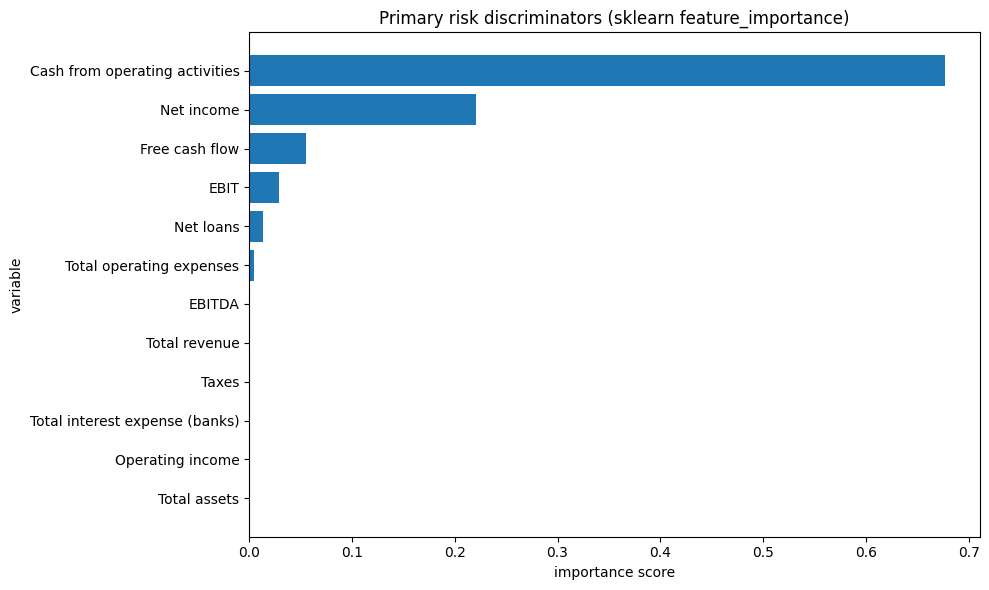

In [121]:
# Decision-tree visibility view: rank + plot primary risk discriminators
# Uses Snorkel-predicted phase labels and excludes abstain (-1) rows.

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

work = df_out[df_out["phase_pred"].isin([0, 1, 2, 3])].copy()
X = work[SCHEMA_COLS]
y = work["phase_pred"].astype(int)

clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=7)
clf.fit(X, y)

rank_df = pd.DataFrame(
    {
        "variable": SCHEMA_COLS,
        "score": clf.feature_importances_,
        "metric": "sklearn feature_importance",
    }
).sort_values("score", ascending=False)

print("Decision tree view: top variables by feature importance")

# Show ranking table + bar chart for quick visibility
rank_top = rank_df.head(12).reset_index(drop=True)
display(rank_top)

plt.figure(figsize=(10, 6))
plt.barh(rank_top["variable"][::-1], rank_top["score"][::-1])
plt.title(f"Primary risk discriminators ({rank_top['metric'].iloc[0]})")
plt.xlabel("importance score")
plt.ylabel("variable")
plt.tight_layout()
plt.show()


In [122]:
# Optional: print compact decision tree rules for quick inspection
from sklearn.tree import export_text

print("Decision tree rules (reusing clf from previous cell):")
print(export_text(clf, feature_names=list(SCHEMA_COLS)))


Decision tree rules (reusing clf from previous cell):
|--- Cash from operating activities <= 146.04
|   |--- Net income <= 32.99
|   |   |--- Net loans <= 1260.04
|   |   |   |--- class: 0
|   |   |--- Net loans >  1260.04
|   |   |   |--- class: 0
|   |--- Net income >  32.99
|   |   |--- Free cash flow <= -1.58
|   |   |   |--- class: 0
|   |   |--- Free cash flow >  -1.58
|   |   |   |--- class: 1
|--- Cash from operating activities >  146.04
|   |--- EBIT <= 202.28
|   |   |--- class: 2
|   |--- EBIT >  202.28
|   |   |--- Total operating expenses <= 1035.55
|   |   |   |--- class: 2
|   |   |--- Total operating expenses >  1035.55
|   |   |   |--- class: 2



In [123]:
# define entity series here
if "statement" in df_out.columns:
    _entity_series = df_out["statement"].astype(str)
else:
    _entity_series = df_out.index.astype(str)

kg_rows = pd.DataFrame(
    {
        "entity_id": _entity_series,
        "role_name": df_out["phase_pred_name"].astype(str),
        "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
    }
)

# --- policy: what is allowed into KG ---
MIN_CONFIDENCE = 0.7 # 0.80
ALLOWED_PHASES = {"expansion", "recovery", "slowdown", "contraction"}

# Optional: if you tagged rows with a chosen rule id, keep only approved rules
# (example IDs from your reviewed clean_rules_df)
USE_RULE_ALLOWLIST = False
APPROVED_RULE_IDS = {1, 2, 17, 25, 32, 43, 45}  # update after manual review

kg_rows = pd.DataFrame(
    {
        "entity_id": _entity_series.astype(str),
        "role_name": df_out["phase_pred_name"].astype(str),
        "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
        # "rule_id": df_out["rule_id"],  # include only if you have this column
    }
)

kg_rows = (
    kg_rows
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["entity_id", "role_name", "confidence"])
)

# keep valid labels only
kg_rows = kg_rows[kg_rows["role_name"].isin(ALLOWED_PHASES)]

# Debug before confidence filtering
if kg_rows.empty:
    print("No rows available before confidence filter.")
else:
    print("Max confidence before filter:", kg_rows["confidence"].max())
    i_before = kg_rows["confidence"].idxmax()
    print("Max-confidence row before filter:\n", kg_rows.loc[i_before])

# keep high-confidence predictions only
kg_rows = kg_rows[kg_rows["confidence"] >= MIN_CONFIDENCE]

# Debug after confidence filtering
if kg_rows.empty:
    print(f"No rows meet MIN_CONFIDENCE >= {MIN_CONFIDENCE}.")
else:
    i_after = kg_rows["confidence"].idxmax()
    print("Max-confidence row after filter:\n", kg_rows.loc[i_after])

# optional rule-based allowlist
if USE_RULE_ALLOWLIST and "rule_id" in kg_rows.columns:
    kg_rows = kg_rows[kg_rows["rule_id"].isin(APPROVED_RULE_IDS)]

kg_rows["entity_id"] = kg_rows["entity_id"].str.slice(0, 300)

print(f"Rows allowed for KG write: {len(kg_rows)}")

Max confidence before filter: 0.7242991057015666
Max-confidence row before filter:
 entity_id               0
role_name     contraction
confidence       0.724299
Name: 0, dtype: object
Max-confidence row after filter:
 entity_id               0
role_name     contraction
confidence       0.724299
Name: 0, dtype: object
Rows allowed for KG write: 30


In [124]:
# --- preview before writing to KG ---
print(f"MIN_CONFIDENCE: {MIN_CONFIDENCE}")
print(f"USE_RULE_ALLOWLIST: {USE_RULE_ALLOWLIST}")
if USE_RULE_ALLOWLIST and "rule_id" in kg_rows.columns:
    print(f"Approved rule count: {len(APPROVED_RULE_IDS)}")
    print(f"Rules present in rows: {sorted(kg_rows['rule_id'].dropna().unique().tolist())[:50]}")

print(f"Rows to write: {len(kg_rows)}")

if kg_rows.empty:
    print("Nothing to write.")
else:
    # full preview (adjust number as needed)
    print("\nSample rows to write:")
    print(kg_rows.head(20).to_string(index=False))

    # optional checks
    print("\nLabel distribution:")
    print(kg_rows["role_name"].value_counts().to_string())

    if "rule_id" in kg_rows.columns:
        print("\nTop rule_id counts:")
        print(kg_rows["rule_id"].value_counts().head(30).to_string())

MIN_CONFIDENCE: 0.7
USE_RULE_ALLOWLIST: False
Rows to write: 30

Sample rows to write:
entity_id   role_name  confidence
        0 contraction    0.724299
       10    slowdown    0.716327
       11    slowdown    0.716327
       16 contraction    0.724299
       17    slowdown    0.716327
       19    slowdown    0.716327
       25    slowdown    0.716327
       30    slowdown    0.716327
       38 contraction    0.724299
       42    slowdown    0.716327
       47   expansion    0.710138
       69    slowdown    0.716327
       81    slowdown    0.716327
       89   expansion    0.710138
       91    slowdown    0.716327
       96    slowdown    0.716327
       99    slowdown    0.716327
      101    slowdown    0.716327
      105   expansion    0.710138
      112 contraction    0.724299

Label distribution:
role_name
slowdown       18
contraction     7
expansion       5


In [125]:

# Optional: write predicted phase as Role nodes into Neo4j KG.
# Enable only when NEO4J_URI / NEO4J_USERNAME / NEO4J_PASSWORD are set.
WRITE_ROLES_TO_NEO4J = False

if WRITE_ROLES_TO_NEO4J:
    import os
    from langchain_community.graphs import Neo4jGraph

    graph = Neo4jGraph(
        url=os.environ["NEO4J_URI"],
        username=os.environ["NEO4J_USERNAME"],
        password=os.environ["NEO4J_PASSWORD"],
    )

    # Use statement text as entity id and phase prediction as role.
    if "statement" in df_out.columns:
        _entity_series = df_out["statement"].astype(str)
    else:
        _entity_series = df_out.index.astype(str)

    kg_rows = pd.DataFrame(
        {
            "entity_id": _entity_series,
            "role_name": df_out["phase_pred_name"].astype(str),
            "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
        }
    )
    kg_rows = kg_rows.replace([np.inf, -np.inf], np.nan).dropna(subset=["entity_id", "role_name", "confidence"])
    kg_rows = kg_rows[kg_rows["role_name"].isin([PHASES[i] for i in [0, 1, 2, 3]])].copy()
    kg_rows["entity_id"] = kg_rows["entity_id"].str.slice(0, 300)

    graph.query("CREATE CONSTRAINT entity_id IF NOT EXISTS FOR (e:Entity) REQUIRE e.id IS UNIQUE")
    graph.query("CREATE CONSTRAINT role_name IF NOT EXISTS FOR (r:Role) REQUIRE r.name IS UNIQUE")

    q_upsert_roles = """
    UNWIND $rows AS row
    MERGE (e:Entity {id: row.entity_id})
    ON CREATE SET e.created_at = datetime()
    SET e.updated_at = datetime(),
        e.source = 'snorkel_financial_cycle_schema_demo'

    MERGE (r:Role {name: row.role_name})

    MERGE (e)-[hr:HAS_ROLE]->(r)
    SET hr.confidence = toFloat(row.confidence),
        hr.method = 'snorkel_phase_pred',
        hr.updated_at = datetime()
    """

    graph.query(q_upsert_roles, {"rows": kg_rows.to_dict("records")})
    print(f"Upserted {len(kg_rows)} Entity-Role links to Neo4j.")

    verify = graph.query(
        """
        MATCH (e:Entity)-[hr:HAS_ROLE]->(r:Role)
        RETURN e.id AS entity, r.name AS role, hr.confidence AS confidence
        ORDER BY confidence DESC
        LIMIT 12
        """
    )
    display(pd.DataFrame(verify))